# Aula 2 — Carregando arquivo CSV no Google Colab para análise de Física

Nesta aula, vamos trabalhar com um **arquivo CSV** contendo dados de um **pêndulo simples**.

A proposta é ensinar, de forma didática, como:

- importar bibliotecas;
- carregar um arquivo `.csv`;
- visualizar os dados;
- interpretar cada coluna;
- fazer estatística básica;
- construir gráficos;
- relacionar os resultados com a Física.

---

## Tema físico desta aula

O tema escolhido foi o **pêndulo simples**.

Para pequenas oscilações, o período do pêndulo é dado por:

$$
T = 2\pi \sqrt{\frac{L}{g}}
$$

onde:

- $T$ = período da oscilação;
- $L$ = comprimento do pêndulo;
- $g$ = aceleração da gravidade.

Nesta base de dados, cada linha representa uma medida experimental simulada.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Caminho do arquivo utilizado nesta aula

Vamos ler o arquivo diretamente deste caminho no Google Drive:

`/content/drive/MyDrive/Colab Notebooks/dados_fisica_pendulo_200_pontos.csv`

> Importante: o arquivo deve estar salvo exatamente nesse local.

In [2]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================
# pandas: leitura e manipulação de tabelas
# matplotlib: criação de gráficos
# numpy: operações numéricas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# 2. DEFINIÇÃO DO CAMINHO DO ARQUIVO
# ============================================================
# Aqui informamos ao Colab onde está o arquivo CSV.
# Como o arquivo está no Google Drive, usamos o caminho completo.
# ============================================================

caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/dados_fisica_pendulo_200_pontos.csv"

print("Caminho definido com sucesso:")
print(caminho_arquivo)

Caminho definido com sucesso:
/content/drive/MyDrive/Colab Notebooks/dados_fisica_pendulo_200_pontos.csv


In [4]:
# ============================================================
# 3. LEITURA DO ARQUIVO CSV
# ============================================================
# O comando pd.read_csv() lê o arquivo e transforma os dados
# em uma tabela do pandas, chamada DataFrame.
# ============================================================

df = pd.read_csv(caminho_arquivo)

print("Arquivo carregado com sucesso.")

Arquivo carregado com sucesso.


In [5]:
# ============================================================
# 4. VISUALIZAÇÃO INICIAL DOS DADOS
# ============================================================
# head() mostra as primeiras linhas da tabela.
# Isso é importante para conferir se o arquivo foi lido corretamente.
# ============================================================

df.head()

,ponto,comprimento_m,periodo_s,tempo_10_oscilacoes_s
0,1,0.6244,1.5647,15.7158
1,2,1.4310,2.4067,24.0543
2,3,1.1248,2.1364,21.3620
3,4,0.9381,1.9216,19.1356
4,5,0.3184,1.1880,11.8783


In [7]:
# ============================================================
# 5. TAMANHO DA BASE DE DADOS
# ============================================================
# shape informa:
# - quantas linhas existem
# - quantas colunas existem
# ============================================================

print("Dimensões da base de dados:", df.shape)

Dimensões da base de dados: (200, 4)


In [8]:
# ============================================================
# 6. NOMES DAS COLUNAS
# ============================================================
# columns mostra os nomes das variáveis disponíveis.
# ============================================================

print("Colunas disponíveis:")
print(df.columns)

Colunas disponíveis:
Index(['ponto', 'comprimento_m', 'periodo_s', 'tempo_10_oscilacoes_s'], dtype='object')


## Interpretação das colunas

Nesta base, temos:

- **ponto**: número identificador da medida;
- **comprimento_m**: comprimento do pêndulo em metros;
- **periodo_s**: período medido em segundos;
- **tempo_10_oscilacoes_s**: tempo total de 10 oscilações em segundos.

Observe que a coluna `tempo_10_oscilacoes_s` é útil para mostrar aos alunos que, em experimentos reais, muitas vezes medimos várias oscilações e depois dividimos para obter o período médio.

In [9]:
# ============================================================
# 7. TIPO DE DADOS DE CADA COLUNA
# ============================================================
# info() ajuda a verificar se as colunas foram lidas
# como números, textos, etc.
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ponto                  200 non-null    int64  
 1   comprimento_m          200 non-null    float64
 2   periodo_s              200 non-null    float64
 3   tempo_10_oscilacoes_s  200 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


In [10]:
# ============================================================
# 8. ESTATÍSTICA DESCRITIVA
# ============================================================
# describe() fornece resumo estatístico:
# média, desvio padrão, mínimo, máximo e quartis.
# ============================================================

df.describe()

,ponto,comprimento_m,periodo_s,tempo_10_oscilacoes_s
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.777608,1.697461,16.970069
std,57.879185,0.412846,0.505834,5.061833
min,1.000000,0.107700,0.644300,6.494400
25%,50.750000,0.420000,1.309575,13.080400
50%,100.500000,0.792250,1.773050,17.704250
75%,150.250000,1.159625,2.156000,21.540675
max,200.000000,1.481600,2.478700,24.740000


In [11]:
# ============================================================
# 9. CÁLCULO DO PERÍODO A PARTIR DE 10 OSCILAÇÕES
# ============================================================
# Em muitos experimentos, mede-se o tempo de várias oscilações
# para reduzir erro experimental.
#
# Aqui vamos criar uma nova coluna com o período médio:
# período = tempo de 10 oscilações / 10
# ============================================================

df["periodo_medio_calculado_s"] = df["tempo_10_oscilacoes_s"] / 10

df.head()

,ponto,comprimento_m,periodo_s,tempo_10_oscilacoes_s,periodo_medio_calculado_s
0,1,0.6244,1.5647,15.7158,1.57158
1,2,1.4310,2.4067,24.0543,2.40543
2,3,1.1248,2.1364,21.3620,2.13620
3,4,0.9381,1.9216,19.1356,1.91356
4,5,0.3184,1.1880,11.8783,1.18783


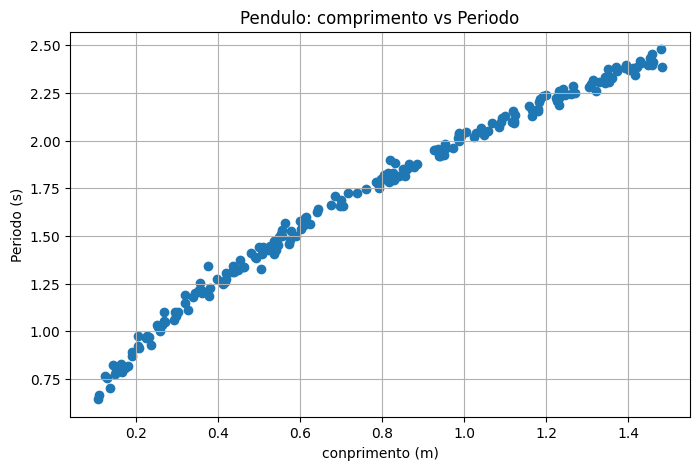

In [13]:
# ============================================================
# 10. GRÁFICO: COMPRIMENTO x PERÍODO
# ============================================================
# Esperamos que o período aumente quando o comprimento aumenta.
# Isso está de acordo com a teoria do pêndulo simples.
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["comprimento_m"], df["periodo_s"])
plt.xlabel("conprimento (m)")
plt.ylabel("Periodo (s)")
plt.title("Pendulo: comprimento vs Periodo")
plt.grid(True)
plt.show()

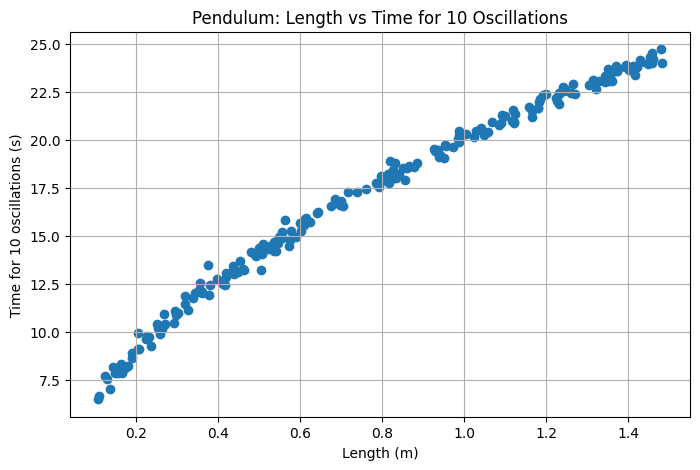

In [14]:
# ============================================================
# 11. GRÁFICO: COMPRIMENTO x TEMPO DE 10 OSCILAÇÕES
# ============================================================
# Esse gráfico ajuda os alunos a perceberem que o tempo total
# de 10 oscilações também cresce conforme o comprimento aumenta.
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["comprimento_m"], df["tempo_10_oscilacoes_s"])
plt.xlabel("Length (m)")
plt.ylabel("Time for 10 oscillations (s)")
plt.title("Pendulum: Length vs Time for 10 Oscillations")
plt.grid(True)
plt.show()

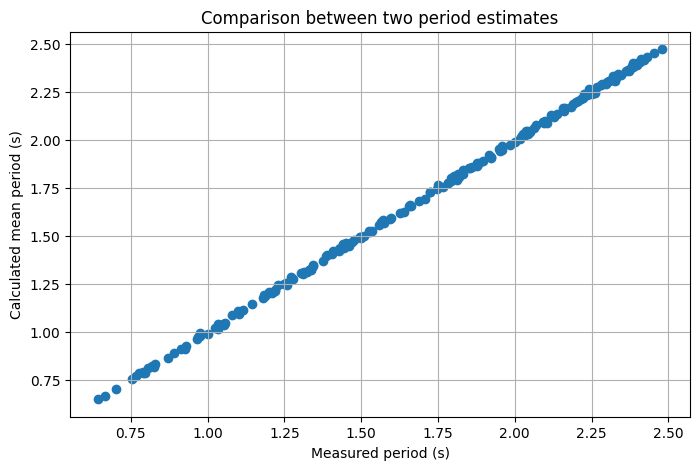

In [15]:
# ============================================================
# 12. COMPARAÇÃO ENTRE DUAS FORMAS DE PERÍODO
# ============================================================
# Vamos comparar:
# - periodo_s: valor medido diretamente
# - periodo_medio_calculado_s: valor obtido dividindo o tempo
#   de 10 oscilações por 10
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["periodo_s"], df["periodo_medio_calculado_s"])
plt.xlabel("Measured period (s)")
plt.ylabel("Calculated mean period (s)")
plt.title("Comparison between two period estimates")
plt.grid(True)
plt.show()

In [16]:
# ============================================================
# 13. TESTANDO A RELAÇÃO T^2 x L
# ============================================================
# Pela teoria:
#
#   T = 2*pi*sqrt(L/g)
#
# Elevando ao quadrado:
#
#   T^2 = (4*pi^2/g) * L
#
# Ou seja, T^2 deve variar linearmente com L.
# Vamos criar a coluna T^2.
# ============================================================

df["periodo_quadrado_s2"] = df["periodo_s"]**2

df.head()

,ponto,comprimento_m,periodo_s,tempo_10_oscilacoes_s,periodo_medio_calculado_s,periodo_quadrado_s2
0,1,0.6244,1.5647,15.7158,1.57158,2.448286
1,2,1.4310,2.4067,24.0543,2.40543,5.792205
2,3,1.1248,2.1364,21.3620,2.13620,4.564205
3,4,0.9381,1.9216,19.1356,1.91356,3.692547
4,5,0.3184,1.1880,11.8783,1.18783,1.411344


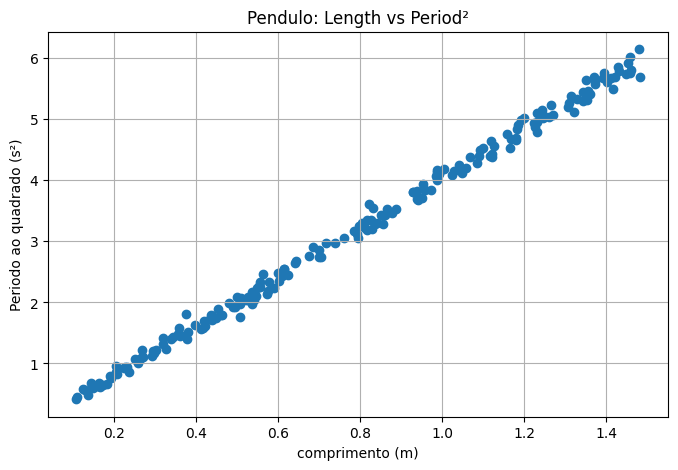

In [18]:
# ============================================================
# 14. GRÁFICO: T^2 x L
# ============================================================
# Este é um gráfico muito importante em laboratório de Física,
# porque ele transforma a equação teórica em uma relação linear.
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(df["comprimento_m"], df["periodo_quadrado_s2"])
plt.xlabel("comprimento (m)")
plt.ylabel("Periodo ao quadrado (s²)")
plt.title("Pendulo: Length vs Period²")
plt.grid(True)
plt.show()

In [19]:
# ============================================================
# 15. AJUSTE LINEAR SIMPLES
# ============================================================
# Vamos ajustar uma reta para T² em função de L.
# np.polyfit(x, y, 1) retorna:
# - coeficiente angular
# - coeficiente linear
# ============================================================

x = df["comprimento_m"]
y = df["periodo_quadrado_s2"]

coef_angular, coef_linear = np.polyfit(x, y, 1)

print("Coeficiente angular:", coef_angular)
print("Coeficiente linear:", coef_linear)

Coeficiente angular: 4.028393267460997
Coeficiente linear: 0.0034503941261892746


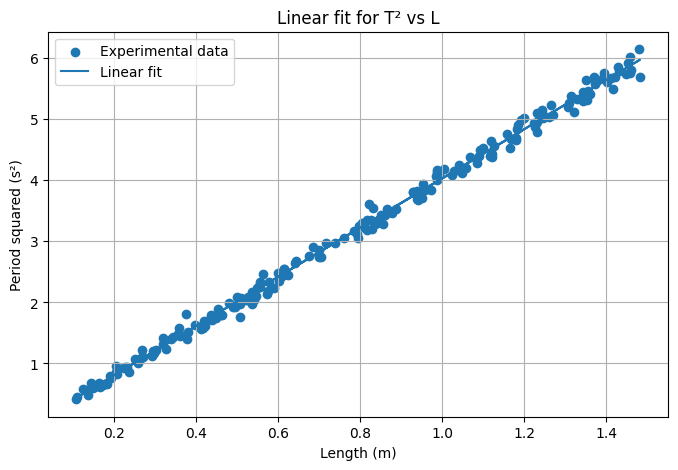

In [20]:
# ============================================================
# 16. DESENHANDO A RETA AJUSTADA
# ============================================================
# Agora vamos visualizar os pontos experimentais e a reta
# ajustada no mesmo gráfico.
# ============================================================

x = df["comprimento_m"]
y = df["periodo_quadrado_s2"]

coef_angular, coef_linear = np.polyfit(x, y, 1)
y_ajuste = coef_angular * x + coef_linear

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Experimental data")
plt.plot(x, y_ajuste, label="Linear fit")
plt.xlabel("Length (m)")
plt.ylabel("Period squared (s²)")
plt.title("Linear fit for T² vs L")
plt.grid(True)
plt.legend()
plt.show()

## Interpretação física do ajuste

Se a teoria estiver coerente com os dados, o gráfico de $T^2$ versus $L$ deve se parecer com uma reta.

Isso é importante porque mostra aos alunos que:

- nem sempre a melhor forma de analisar uma equação é na forma original;
- às vezes transformamos os dados para identificar relações lineares;
- gráficos podem ajudar a confirmar modelos físicos.

No caso do pêndulo simples:

$$
T^2 = \frac{4\pi^2}{g}L
$$

Então o coeficiente angular da reta tem relação com a gravidade.

In [21]:
# ============================================================
# 17. ESTIMATIVA DA GRAVIDADE A PARTIR DO AJUSTE
# ============================================================
# Da equação:
#
#   T² = (4*pi²/g) * L
#
# temos:
#
#   g = 4*pi² / coef_angular
# ============================================================

g_estimado = 4 * np.pi**2 / coef_angular

print("Valor estimado de g (m/s²):", g_estimado)

Valor estimado de g (m/s²): 9.800040607564556


## Discussão final para a aula

Com esta atividade, os estudantes podem aprender ao mesmo tempo:

1. como carregar um arquivo CSV no Colab;
2. como manipular tabelas com pandas;
3. como construir gráficos;
4. como interpretar dados experimentais;
5. como ligar os resultados com uma equação física.

---

## Possíveis perguntas para os alunos

- O período aumenta ou diminui com o comprimento?
- O gráfico $T$ versus $L$ é linear?
- O gráfico $T^2$ versus $L$ parece mais linear?
- Por que medir 10 oscilações pode ser melhor do que medir apenas 1?
- O valor estimado de $g$ ficou próximo do esperado?

---

## Próximo passo sugerido

Na próxima aula, você pode ensinar:

- comparação entre dados teóricos e experimentais;
- cálculo de erro percentual;
- ajuste de curvas;
- análise de incertezas.